In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

In [60]:
df = pd.read_csv("../Veriler/06-study_hours_grades.csv")
df.head()

,study_hours,grade
0,3.745401,30.203939
1,9.507143,57.878452
2,7.319939,46.368401
3,5.986585,39.330717
4,1.560186,14.843888


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  50 non-null     float64
 1   grade        50 non-null     float64
dtypes: float64(2)
memory usage: 932.0 bytes


In [77]:
# dtype ve shape konusuna dikkat etmemiz gerekiyor.
x = torch.tensor(df['study_hours'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['grade'].values, dtype=torch.float32).unsqueeze(1)

In [78]:
x.ndim

2

In [79]:
x.shape

torch.Size([50, 1])

In [80]:
train_split = int(len(x) * 0.8)
X_train, Y_train = x[:train_split], y[:train_split]
X_test, Y_test = x[train_split:],y[train_split:]

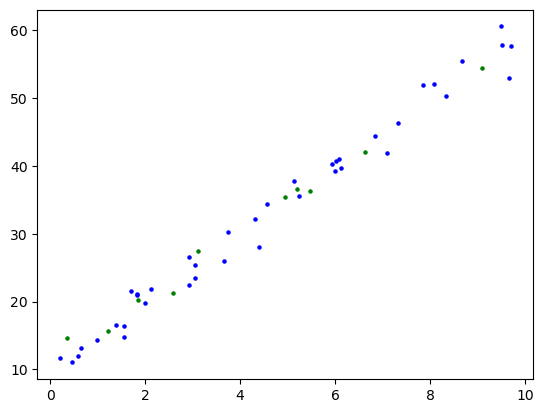

In [81]:
plt.scatter(X_train,Y_train, c="b",s=5, label = "Train Data")
plt.scatter(X_test,Y_test, c="g",s=5, label = "Test Data")
plt.show()

In [82]:
import torch.nn as nn

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.linear_layer_1 = nn.Linear(in_features=1, out_features=1)

    def forward(self,x:torch.Tensor) -> torch.Tensor:
        return self.linear_layer_1(x)

In [83]:
torch.manual_seed(42)
model = LinearRegressionModel()

In [84]:
model

LinearRegressionModel(
  (linear_layer_1): Linear(in_features=1, out_features=1, bias=True)
)

In [85]:
model.state_dict()

OrderedDict([('linear_layer_1.weight', tensor([[0.7645]])),
             ('linear_layer_1.bias', tensor([0.8300]))])

In [86]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(params = model.parameters(), lr = 0.001)

In [88]:
epochs = 120

for epoch in range(epochs):
    
    model.train() # modeli eğitim moduna alıyoruz.
    y_pred = model(X_train) # ileri yayılım
    loss = loss_fn(y_pred,Y_train) # hata(loss) hesaplıyoruz.

    optimizer.zero_grad() # gradyanları sıfırlama
    loss.backward() # geri yayılım.
    optimizer.step() # hesaplanan türevleri(gradyanları) kullanarak geri yayılım yapıyoruz.

    model.eval()
    with torch.inference_mode():
        test_pred = model(X_test)
        test_loss = loss_fn(test_pred, Y_test)

        if epoch % 5 == 0:
            print(f"Epoch: {epoch}, Train Loss {loss}, Test Loss {test_loss} ")

Epoch: 0, Train Loss 965.6339721679688, Test Loss 717.683349609375 
Epoch: 5, Train Loss 530.086669921875, Test Loss 405.685546875 
Epoch: 10, Train Loss 295.7361755371094, Test Loss 236.03225708007812 
Epoch: 15, Train Loss 169.61843872070312, Test Loss 143.42544555664062 
Epoch: 20, Train Loss 101.72415924072266, Test Loss 92.61088562011719 
Epoch: 25, Train Loss 65.15110778808594, Test Loss 64.53107452392578 
Epoch: 30, Train Loss 45.427330017089844, Test Loss 48.86598587036133 
Epoch: 35, Train Loss 34.767799377441406, Test Loss 40.014488220214844 
Epoch: 40, Train Loss 28.984628677368164, Test Loss 34.92718505859375 
Epoch: 45, Train Loss 25.824926376342773, Test Loss 31.93711280822754 
Epoch: 50, Train Loss 24.0767879486084, Test Loss 30.128173828125 
Epoch: 55, Train Loss 23.088253021240234, Test Loss 28.993366241455078 
Epoch: 60, Train Loss 22.508625030517578, Test Loss 28.2496337890625 
Epoch: 65, Train Loss 22.149234771728516, Test Loss 27.737096786499023 
Epoch: 70, Train L

In [73]:
X_train.dtype

torch.float32

In [76]:
X_train.unsqueeze(1).shape

torch.Size([40, 1])